# Letterboxd User Move Recommender DS3000
## Kaan Tural, Kyra Grimes, Lin Pan, and Shravan Ganta

In this project we aim to web scrape a given user's letterboxd diary (if you aren't familiar it is essentially a social media for movies) to build a personalized movie recommender. The two main questions we aim to answer are: How can we utilize basic movie features (ex. genre, length, release year) to recommend movies to a specific user based on their diary of movies watched? Secondly, we aim to investiage if we can use this information to accurately predict a user's rating for any given movie. If these questions do not pose challenging enough to solve, we have discussed factoring in review sentiment analysis to the movie recommender.

For our data processing, we begin by scraping the given user's complete letterboxd history into a dataframe (see letterboxd.com). Then for every film the user has watched, we scrape the important film data (including genre and year released) and add that to our dataframe.

In [1]:
import requests
import pandas as pd
import math
import re
import numpy as np
from bs4 import BeautifulSoup
import unicodedata

# for plotting
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Collection

In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def get_user_diary(username):
    """Creates a DataFrame of a user's Letterboxd diary given their username

    Args: 
        username (string): Letterboxd username

    Returns:
        df (DataFrame): DataFrame containing the information in a user's diary (movies, ratings, etc.)
    """

    # Finding the max page number
    url = f'https://letterboxd.com/{username}/films/diary/'
    html = requests.get(url).text
    soup = BeautifulSoup(html, 'html.parser')
    pagination = soup.find('div', class_='pagination')
    if pagination:
        max_page = int(pagination.find_all('li', class_='paginate-page')[-1].text) 
    else:
        max_page = 1

    all_data = [] 
    current_month = None 

    for i in range(1, max_page + 1):
        url = f'https://letterboxd.com/{username}/films/diary/page/{i}'
        html = requests.get(url).text
        soup = BeautifulSoup(html, 'html.parser')

        month_watched = soup.find_all(class_='td-calendar')
        day_watched = soup.find_all(class_='td-day diary-day center')
        films = soup.find_all('h3', class_='headline-3 prettify')
        released_dates = soup.find_all(class_='td-released center')
        ratings = soup.find_all('span', class_='rating')

        film_slug_list = []

        for j in range(len(films)): 
            if month_watched:
                current_month = month_watched[j].get_text(strip=True) if month_watched[j].get_text(strip=True) else current_month
              
            # getting film title for genre lookup
            film_title = films[j].get_text(strip=True)
            film_slug = '-'.join(re.sub(r'\s*:\s*', '-', film_title).lower().split())

            # Convert non-ASCII characters to ASCII equivalents
            film_slug = unicodedata.normalize('NFKD', film_slug).encode('ascii', 'ignore').decode('ascii')
            film_slug = film_slug.replace('.', '') 
            film_slug_list.append(film_slug)
            
            # fetching genres using the name of the film
            genre_url = f'https://letterboxd.com/film/{film_slug}/genres/'
            genre_html = requests.get(genre_url).text
            genre_soup = BeautifulSoup(genre_html, 'html.parser')
            genres = genre_soup.find('div', class_='text-sluglist capitalize')
            
            if genres:
                genre_list = [genre.text for genre in genres.find_all('a', class_='text-slug')]
                genres_str = ', '.join(genre_list) # joining the genres with commas
                
            else:
                genres_str = None
            
            data = {
                'Month': current_month,
                'Day': day_watched[j].get_text(strip=True) if j < len(day_watched) else None,
                'Film': film_title,
                'Released': released_dates[j].get_text(strip=True) if j < len(released_dates) else None,
                'Ratings': ratings[j].get_text(strip=True) if j < len(ratings) else None,
                'Genres': genres_str 
            }
            all_data.append(data)
            
    df = pd.DataFrame(all_data)
    return df, film_slug_list

df, film_slug_list = get_user_diary('kmgrimes')
print(df)

       Month Day                   Film Released Ratings  \
0    Nov2024  25           Gladiator II     2024    ★★★½   
1    Nov2024  21                 Wicked     2024    ★★★★   
2    Nov2024  20           The Hangover     2009    ★★★★   
3    Nov2024  18             Don't Move     2024      ★★   
4    Oct2024  23         Piece By Piece     2024     ★★★   
..       ...  ..                    ...      ...     ...   
177  Feb2022  12  But I'm a Cheerleader     1999    ★★★★   
178  Feb2022  06                Maurice     1987     ★★★   
179  Oct2021  30                  Ponyo     2008   ★★★★★   
180  Oct2021  26            Open Season     2006     ★★★   
181  Jan2020  19         It Chapter Two     2019   ★★★★★   

                                   Genres  
0                       Action, Adventure  
1                                Thriller  
2                                  Comedy  
3                                    None  
4                             Documentary  
..             

In [4]:
df.head(10)

,Month,Day,Film,Released,Ratings,Genres
0,Nov2024,21,Wicked,2024,★★★★,Thriller
1,Nov2024,20,The Hangover,2009,★★★★,Comedy
2,Nov2024,18,Don't Move,2024,★★,None
3,Oct2024,23,Piece By Piece,2024,★★★,Documentary
4,Oct2024,10,Carmen Jones,1954,★★★★,"Drama, Romance"
5,Oct2024,04,Les Misérables,2012,★★★★½,"Drama, History"
6,Oct2024,03,Office Space,1999,★★★,Comedy
7,Sep2024,29,Rio,2011,★★★,"Crime, Romance"
8,Sep2024,26,Scooby-Doo! Camp Scare,2010,★★★★,None
9,Sep2024,18,Island of Lost Souls,1932,,"Horror, Science Fiction"


## Cleaning

In [5]:
def clean_diary_data(df):
    """Cleans the DataFrame containing Letterboxd diary data.

    Args:
        df (DataFrame): DataFrame from get_user_diary function.

    Returns:
        df (DataFrame): Cleaned DataFrame.
    """

    # extracting month and year into separate columns
    df[['Month', 'Year']] = df['Month'].str.extract('([a-zA-Z]+)(\d{4})')
    month_mapping = {
        'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
        'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
    }
    df['Month'] = df['Month'].map(month_mapping)
    df['Year'] = df['Year'].astype(int)

    # Convert star ratings to numerical values (handle NaN)
    def convert_rating(rating_str):
        if not rating_str:
            return 0  # Replace NaN with 0
        full_stars = rating_str.count('★')
        half_star = 0.5 if '½' in rating_str else 0
        return full_stars + half_star

    df['Ratings'] = df['Ratings'].apply(convert_rating)

    return df

In [6]:
def remove_duplicate_movies(df):
    """Removes duplicate movie entries from the DataFrame.

    Args:
        df (DataFrame): DataFrame with movie entries.

    Returns:
        df (DataFrame): DataFrame with duplicate movie entries removed. 
    """
    # Remove duplicates based on 'Film', 'Year', 'Month', and 'Day'
    df = df.drop_duplicates(subset=['Film', 'Year', 'Month', 'Day'], keep='first') 
    return df

In [7]:
df = clean_diary_data(df)
df['Released'] = pd.to_numeric(df['Released'])
df['Day'] = pd.to_numeric(df['Day'])

# uncomment below for removing duplicate movies
# df = remove_duplicate_movies(df)

df.head(10)

,Month,Day,Film,Released,Ratings,Genres,Year
0,11,21,Wicked,2024,4.0,Thriller,2024
1,11,20,The Hangover,2009,4.0,Comedy,2024
2,11,18,Don't Move,2024,2.0,None,2024
3,10,23,Piece By Piece,2024,3.0,Documentary,2024
4,10,10,Carmen Jones,1954,4.0,"Drama, Romance",2024
5,10,4,Les Misérables,2012,4.5,"Drama, History",2024
6,10,3,Office Space,1999,3.0,Comedy,2024
7,9,29,Rio,2011,3.0,"Crime, Romance",2024
8,9,26,Scooby-Doo! Camp Scare,2010,4.0,None,2024
9,9,18,Island of Lost Souls,1932,0.0,"Horror, Science Fiction",2024


## Plotting and EDA

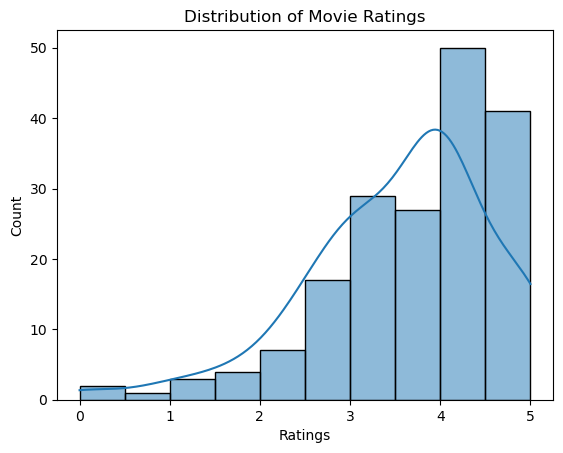

In [8]:
# Histogram of Movie Ratings
sns.histplot(df['Ratings'], bins=10, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

Here we can see this user data is skewed to the left with the most common rating being a 4.5. 

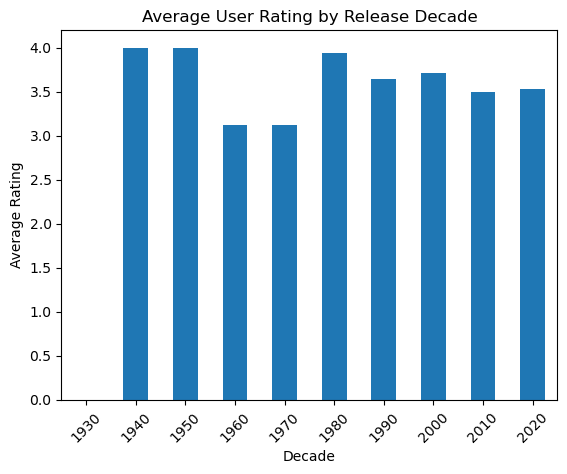

In [9]:
# Bar charts of average user rating by Release Decade
# visualize which decades the user tends to favor, allowing us to suggest movies from those periods

# create the decade column
df['Decade'] = (df['Released'] // 10) * 10

# get the average rating for each release dacade
avg_rating_by_decade = df.groupby('Decade')['Ratings'].mean()

# plot the average 
avg_rating_by_decade.plot(kind='bar')
plt.title('Average User Rating by Release Decade')
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

The data here is not skewed in either direction. This graph doesn't illuminate a ton about the dataset, but it could be really interested compared to the number of movies watched in each decade.

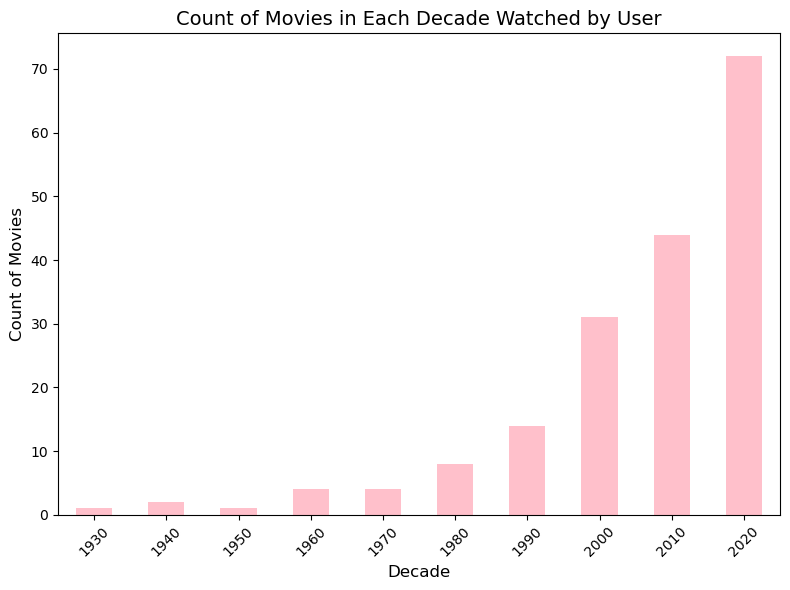

In [10]:
# create the decade column
df['Decade'] = (df['Released'] // 10) * 10

# get the count for each release dacade
count_by_decade = df['Decade'].value_counts().sort_index()

# plot the count 
plt.figure(figsize=(8, 6))
count_by_decade.plot(kind='bar', color='pink')

# make pretty
plt.title('Count of Movies in Each Decade Watched by User', fontsize=14)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Count of Movies', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Display the plot
plt.tight_layout()
plt.show()

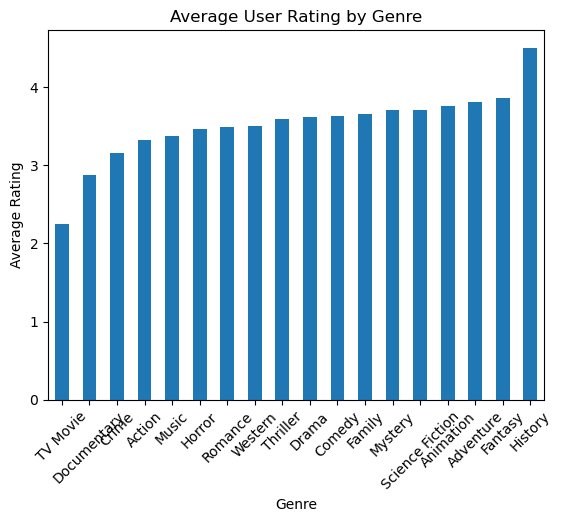

In [11]:
# Bar chart of average user rating by Genre
# if certain genres receive higher average ratings, we can recommend more movies from those genres

# split the genres into separate rows
df_exploded = df.assign(Genres=df['Genres'].str.split(', ')).explode('Genres')

# get the average rating for each genre
genre_avg_rating = df_exploded.groupby('Genres')['Ratings'].mean()

# plot the average
genre_avg_rating.sort_values().plot(kind='bar')
plt.title('Average User Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Here we see the unique genres that a movie could possible be tagged with

df_exploded = df.assign(Genres=df['Genres'].str.split(', ')).explode('Genres')

unique_genres = df_exploded['Genres'].unique()
unique_genres

array(['Thriller', 'Comedy', None, 'Documentary', 'Drama', 'Romance',
       'History', 'Crime', 'Horror', 'Science Fiction', 'Action',
       'Fantasy', 'Adventure', 'Family', 'Animation', 'Mystery', 'Music',
       'TV Movie', 'Western'], dtype=object)

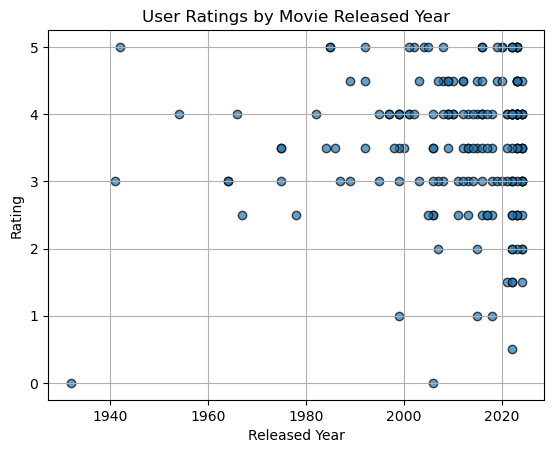

In [13]:
# Scatter plot of ratings by released year
plt.scatter(df['Released'], df['Ratings'], alpha=0.7, edgecolors='k')
plt.title('User Ratings by Movie Released Year')
plt.xlabel('Released Year')
plt.ylabel('Rating')
plt.grid(True)
plt.show()

Here we see that the user's data clusters around the more recent decades. 

And finally we can build a normalized covariance matrix that will allow us to see the linear relationships between variables. 

In [14]:

# Select only numeric columns for scaling
numeric_cols = df.select_dtypes(include='number')

numeric_cols.var()

Month        11.322099
Day          80.801473
Released    290.798834
Ratings       1.041958
Year          0.710006
Decade      312.179251
dtype: float64

In [15]:
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

In [16]:
def line_of_best_fit(X, y):
    """
    Args:
        X (array): can be either 1-d or 2-d array
        y (array): 1-d array that includes corresponding values to X
        
    Returns:
        m (vector): vector containing the coefficients for the line of best fit
    """
    
    Xnew = add_bias_column(X)
    
    XtXinv = np.linalg.inv(np.matmul(Xnew.T, Xnew))
    m = np.matmul(XtXinv, np.matmul(Xnew.T, y))
    return m

In [17]:
from sklearn.metrics import r2_score

def linreg_predict(Xnew, ynew, m):
    """
    Args:
        Xnew (array): either 1-d or 2-d with all p predictor values
        ynew (array): 1-d array with corresponding values to Xnew
        m (array): 1-d array of length p+1
        
    Returns:
        linreg_dict (dictionary): consists of 'ypreds', 'resids', 'mse', and 'r2'
    """
    
    X = add_bias_column(Xnew)
     
    r2 = []
    
    ypreds = np.dot(X, m)
    
    resids = ynew - ypreds
    
    mse = np.mean(resids ** 2)
    
    r2 = r2_score(ynew, ypreds)
    
    linreg_dict = {
        'ypreds': ypreds,
        'resids': resids,
        'mse': mse,
        'r2': r2 
    }
    
    return linreg_dict

In [35]:
# get the top-250 movies data frm Flickfocus
url = 'https://flickfocus.com/movies/explore/top-rated'
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

In [ ]:
#a function to extract the data
def extract_top_rated_movies(soup):
    """Extract movie data from FlickFocus movie pages.
    
    Args:
        soup (BeautifulSoup): Parsed HTML response from FlickFocus containing
                            'Title','Link', 'IMDb Rating', 'Release Date', 
                            'Language','Budget', 'Revenue', 'Production Companies','Countries'
        
    Returns:
        DataFrame: DataFrame containing movie information.
    """
    #initialize lists
    movie_list = []
    link_list = []
    rating_list = []
    release_date_list = []
    language_list = []
    budget_list = []
    revenue_list = []
    companies_list = []
    countries_list = []
    
    #extract movie titles and links from the main page
    for movie in soup.find_all('a', class_='block hover:opacity-75'):
        title = movie.get('title', 'No Title')
        link = movie.get('href', 'No Link')
        
        #go to the individual movie page for more info
        movie_page = requests.get(link)
        movie_soup = BeautifulSoup(movie_page.content, 'html.parser')
        
        #extract IMDb rating
        rating = None
        rating_div = movie_soup.find('div', class_='ml-1 font-bold text-xs lg:text-sm')
        if rating_div:
            rating = rating_div.text.strip()
        
        #extract only the in theatres release date
        in_theatres_release_date = None
        theatre_release_div = movie_soup.find('div', string='In Theatres')
        if theatre_release_div:
            date_div = theatre_release_div.find_next_sibling('div')
            if date_div:
                in_theatres_release_date = date_div.text.strip()
        
        #extract language
        language = None
        language_div = movie_soup.find('a', class_='text-blue-500 hover:underline')
        if language_div:
            language = language_div.text.strip()
        
        #extract budget
        budget_value = None
        budget_div = movie_soup.find('div', string='Budget')
        if budget_div:
            budget_amount_div = budget_div.find_next_sibling('div')
            if budget_amount_div:
                budget_text = budget_amount_div.text.strip()
                if "$" in budget_text:
                    budget_value = float(budget_text.replace("$", "").replace(",", ""))
        
        #extract revenue
        revenue_value = None
        revenue_div = movie_soup.find('div', string='Revenue')
        if revenue_div:
            revenue_amount_div = revenue_div.find_next_sibling('div')
            if revenue_amount_div:
                revenue_text = revenue_amount_div.text.strip()
                if "$" in revenue_text:
                    revenue_value = float(revenue_text.replace("$", "").replace(",", ""))
        
        #extract production companies
        companies = []
        companies_div = movie_soup.find('div', string='Companies')
        if companies_div:
            companies_links_div = companies_div.find_next_sibling('div')
            if companies_links_div:
                for company in companies_links_div.find_all('a'):
                    companies.append(company.text.strip())
        
        #extract countries
        countries = []
        countries_div = movie_soup.find('div', string='Countries')
        if countries_div:
            countries_links_div = countries_div.find_next_sibling('div')
            if countries_links_div:
                for country in countries_links_div.find_all('a'):
                    countries.append(country.text.strip())
        
        #append extracted data to lists
        movie_list.append(title)
        link_list.append(link)
        rating_list.append(float(rating) if rating else None)#check if there is rating in numeric value 
        release_date_list.append(in_theatres_release_date)
        language_list.append(language)
        budget_list.append(budget_value)
        revenue_list.append(revenue_value)
        
        #use join so it more fits to the dataframe 
        companies_list.append(', '.join(companies) if companies else None)#check if there is company
        countries_list.append(', '.join(countries) if countries else None)#check if there is country
    
    #store the extracted data into a dictionary and convert to a DataFrame
    movie_dict = {
        'Title': movie_list,
        'Link': link_list,
        'IMDb Rating': rating_list,
        'In Theatres Release Date': release_date_list,
        'Language': language_list,
        'Budget': budget_list,
        'Revenue': revenue_list,
        'Production Companies': companies_list,
        'Countries': countries_list
    }
    
    df_movies = pd.DataFrame.from_dict(movie_dict)
    
    return df_movies

movie_data = extract_top_rated_movies(soup)
movie_data



,Title,Link,IMDb Rating,In Theatres Release Date,Language,Budget,Revenue,Production Companies,Countries
0,The Shawshank Redemption,https://flickfocus.com/movies/the-shawshank-re...,9.3,"Oct 14, 1994 (R)",English,25000000.0,28341469.0,Castle Rock Entertainment,United States
1,The Godfather,https://flickfocus.com/movies/the-godfather,9.2,"Feb 25, 2022 (R)",English,6000000.0,245066411.0,"Paramount Pictures, Alfran Productions",United States
2,12 Angry Men,https://flickfocus.com/movies/12-angry-men,9.0,"Apr 10, 1957 (NR)",English,397751.0,4360000.0,"United Artists, Orion-Nova Productions",United States
3,The Godfather Part II,https://flickfocus.com/movies/the-godfather-pa...,9.0,"Dec 20, 1974 (R)",English,13000000.0,102600000.0,"Paramount Pictures, American Zoetrope, The Cop...",United States
4,Schindler's List,https://flickfocus.com/movies/schindler-s-list,9.0,"Feb 4, 1994 (R)",English,22000000.0,321365567.0,Amblin Entertainment,United States
...,...,...,...,...,...,...,...,...,...
245,Neon Genesis Evangelion: The End of Evangelion,https://flickfocus.com/movies/neon-genesis-eva...,NaN,None,None,NaN,NaN,None,None
246,The Battle of Algiers,https://flickfocus.com/movies/the-battle-of-al...,NaN,None,None,NaN,NaN,None,None
247,The Wages of Fear,https://flickfocus.com/movies/the-wages-of-fear,NaN,None,None,NaN,NaN,None,None
248,Fanny and Alexander,https://flickfocus.com/movies/fanny-and-alexander,NaN,None,None,NaN,NaN,None,None


In [43]:
print(movie_data.iloc[249])

Title                                          All Quiet on the Western Front
Link                        https://flickfocus.com/movies/all-quiet-on-the...
IMDb Rating                                                               NaN
In Theatres Release Date                                                 None
Language                                                                 None
Budget                                                                    NaN
Revenue                                                                   NaN
Production Companies                                                     None
Countries                                                                None
Name: 249, dtype: object


In [28]:
# from sklearn.model_selection import train_test_split


# genre_list = df['Genres'].str.split(',').explode().str.strip().unique()

# print(df)
# #X = df[list(genre_list)].to_numpy()

y = df['Ratings'].to_numpy
print(y)

#Xnew = add_bias_column(X)


# Xtrain, Xtest, ytrain, ytest = train_test_split(Xnew, Y, test_size=0.3, random_state=42)

# m = line_of_best_fit(Xtrain, ytrain)

# linreg_dict = linreg_predict(Xtest, ytest, m)

# print(linreg_dict['mse'])
# print()
# print(linreg_dict['r2'])


<bound method IndexOpsMixin.to_numpy of 0      4.0
1      4.0
2      2.0
3      3.0
4      4.0
      ... 
176    4.0
177    3.0
178    5.0
179    3.0
180    5.0
Name: Ratings, Length: 181, dtype: float64>
